# Plotting

In [2]:
# THIS IS A TEST NOTEBOOK. Thank you to Marla Geha for it!
#
# FOR PS#1, MAKE THE MODIFICATIONS REQUESTED BELOW.
# ONCE YOU HAVE COMPLETED YOUR WORK SAVE THIS AS A .ipynb file.
# (UNDER FILE > DOWNLOAD AS > IPYTHON NOTEBOOK)
# UPLOAD YOUR .ipynb FILE TO CANVAS.

# LOAD BASIC MODULES
import numpy as np
import matplotlib.pyplot as plt

# THIS LINE ALLOWS PLOTS TO APPEAR WITHIN YOUR NOTEBOOK
%matplotlib inline

In [3]:
# GENERATE SOME FAKE DATA
# RANDOM NUMBERS DRAWN FROM A GAUSSIAN DISTRIBUTION
x = np.random.normal(0,1,10**6)    

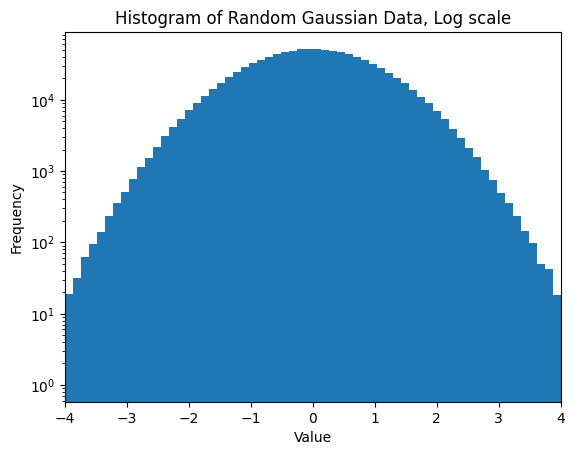

In [4]:
# PLOT A HISTOGRAM OF THE DATA.
#
# FOR PS#1, PLEASE ADD THE FOLLOWING
#           1.  Add X-AXIS LABEL
#           2.  Add PLOT TITLE
#           3.  MODIFY THE X-RANGE TO PLOT ONLY BETWEEN (-4,4)
#           4.  ONE ADDITIONAL MODIFICATION OF YOUR CHOICE

n, bins, tmp = plt.hist(x,bins=75)
plt.ylabel('Frequency')
plt.xlabel('Value') # 1
plt.title('Histogram of Random Gaussian Data, Log scale') # 2
plt.xlim(-4,4) # 3
plt.yscale('log') # 4

# Unit Conversions

In [5]:
# Easy unit conversion and constants
from astropy import units as u
from astropy import constants as const

In [6]:
c = const.c
c

<<class 'astropy.constants.codata2018.CODATA2018'> name='Speed of light in vacuum' value=299792458.0 uncertainty=0.0 unit='m / s' reference='CODATA 2018'>

In [7]:
print(c)

  Name   = Speed of light in vacuum
  Value  = 299792458.0
  Uncertainty  = 0.0
  Unit  = m / s
  Reference = CODATA 2018


In [8]:
c_au_yr = c.to(u.AU/u.yr)
c_au_yr

<Quantity 63241.07708427 AU / yr>

In [9]:
c_au_yr.value, c_au_yr.unit

(np.float64(63241.07708426628), Unit("AU / yr"))

In [10]:
from astropy.units import imperial

In [11]:
c_au_yr.to(imperial.foot/u.hour)

<Quantity 3.5408558e+12 ft / h>

In [12]:
l = 3 * u.km
l.to(imperial.inch)

<Quantity 118110.23622047 inch>

In [13]:
h = 70 * u.km / u.s / u.Mpc
(1/h).to(u.Gyr)

<Quantity 13.96846031 Gyr>

# Loading in Data

In [14]:
# Read in data from a .txt file and plot it (data available on Canvas)
data = np.genfromtxt(
    "planets.csv", ## file name
    delimiter=",", ## separator 
    names=True, ## reads header
    dtype=None, ## doesn't assume a data type
    encoding="utf-8" ## properly read strings
)

In [15]:
header = data.dtype.names ## header

In [16]:
## print the contents of the file
for j in range(8): 
    for i in range(len(header)):
        ## f string formatting: (https://www.geeksforgeeks.org/python/formatted-string-literals-f-strings-python/)
        print(f"{header[i]:<{22}}: {data[j][i]:<{10}}") 
    print('')

Name                  : Mercury   
Diameter_km           : 4879      
Distance_from_Sun_AU  : 0.39      
Mass_1e24kg           : 0.33      
Orbital_Period_days   : 88        
Mean_Temp_C           : 167       

Name                  : Venus     
Diameter_km           : 12104     
Distance_from_Sun_AU  : 0.72      
Mass_1e24kg           : 4.87      
Orbital_Period_days   : 225       
Mean_Temp_C           : 464       

Name                  : Earth     
Diameter_km           : 12742     
Distance_from_Sun_AU  : 1.0       
Mass_1e24kg           : 5.97      
Orbital_Period_days   : 365       
Mean_Temp_C           : 15        

Name                  : Mars      
Diameter_km           : 6779      
Distance_from_Sun_AU  : 1.52      
Mass_1e24kg           : 0.64      
Orbital_Period_days   : 687       
Mean_Temp_C           : -65       

Name                  : Jupiter   
Diameter_km           : 139820    
Distance_from_Sun_AU  : 5.2       
Mass_1e24kg           : 1898.0    
Orbital_Period_d

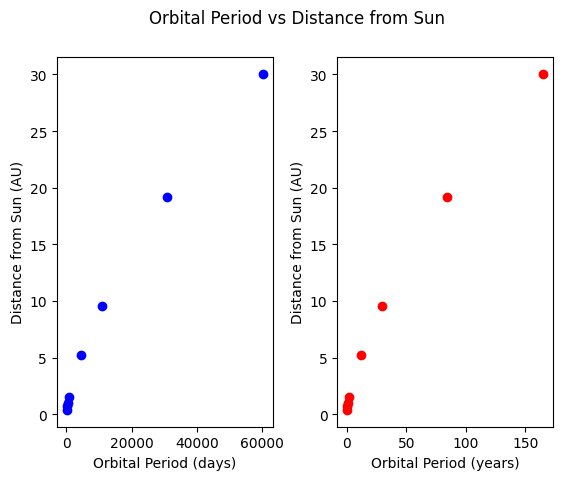

In [17]:
# FOR PS#1, PLEASE DO THE FOLLOWING
#           1.  Plot the distance from the Sun in AU vs orbital period in days
#           2.  Plot the distance from the Sun in AU vs orbital period in years
#           3.  Add PLOT TITLE
#           4.  Add labels to the x- and y-axes

# plt.plot(data[0][0], data[0][1], 'o')
plt.subplot(1, 2, 1)
for i in range(len(data)):
    plt.plot(data[i][4], data[i][2], 'o', color='blue')
    plt.ylabel('Distance from Sun (AU)')
    plt.xlabel('Orbital Period (days)')
plt.subplot(1, 2, 2)
for i in range(len(data)):
    plt.plot(data[i][4] / 365.25, data[i][2], 'o', color='red')
    plt.ylabel('Distance from Sun (AU)')
    plt.xlabel('Orbital Period (years)')
plt.subplots_adjust(wspace=0.3)
plt.suptitle('Orbital Period vs Distance from Sun')
plt.show()

Mars
Jupiter
Saturn
Uranus
Neptune


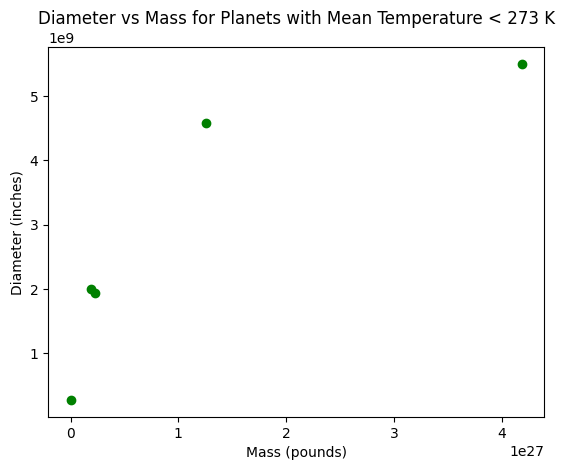

In [18]:
# FOR PS#1, PLEASE DO THE FOLLOWING
#           1.  Select planets with Mean Temperatures less than 273 K
#           2.  Plot the Diameter (in inches) of these planets against their mass in pounds
planet_diameters = []
planet_masses = []

for i in range(len(data)):
    if data[i][5] < 0:
        print(data[i][0]) # sanity check: print planet names with Tmean < 273 K
        diameter_in_inches = (data[i][1] * u.km).to(imperial.inch).value
        mass_in_pounds = (data[i][3] * 1e24 * u.kg).to(imperial.pound).value

        planet_diameters.append(diameter_in_inches)
        planet_masses.append(mass_in_pounds)

plt.plot(planet_masses, planet_diameters, 'o', color='green')
plt.xlabel('Mass (pounds)')
plt.ylabel('Diameter (inches)')
plt.title('Diameter vs Mass for Planets with Mean Temperature < 273 K')
plt.show()